# **Box Plots**


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-02-05 06:28:00--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  44.0MB/s    in 4.5s    

2026-02-05 06:28:07 (44.5 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [4]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [5]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [6]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


In [7]:
QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)

In [8]:
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')
df = df.dropna(subset=['CompTotal'])

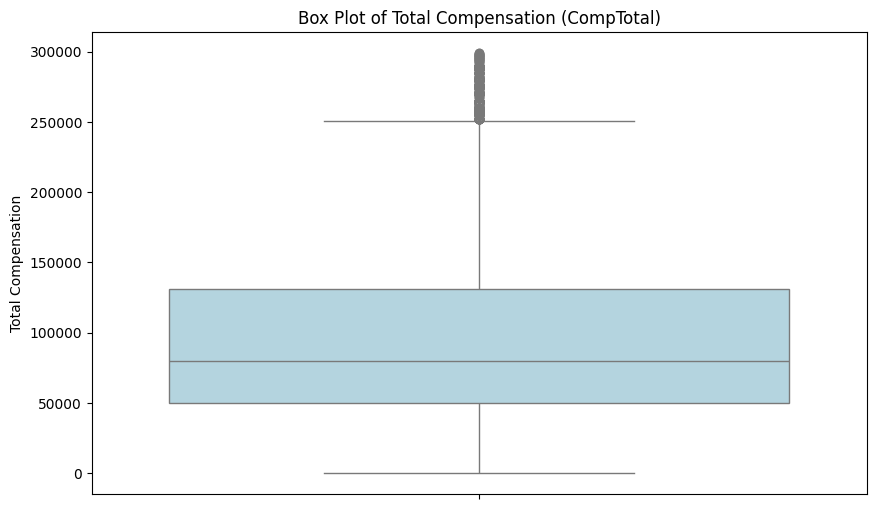

In [12]:
plt.figure(figsize=(10,6))

# sns.boxplot(y=df['CompTotal'], color="lightblue")
sns.boxplot(y=df[df['CompTotal'] < 300000]['CompTotal'], color="lightblue")

plt.title("Box Plot of Total Compensation (CompTotal)")
plt.ylabel("Total Compensation")
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


In [13]:
QUERY = """
SELECT Age
FROM main
WHERE Age IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)


In [14]:
age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

df['Age_numeric'] = df['Age'].map(age_map)
df = df.dropna(subset=['Age_numeric'])

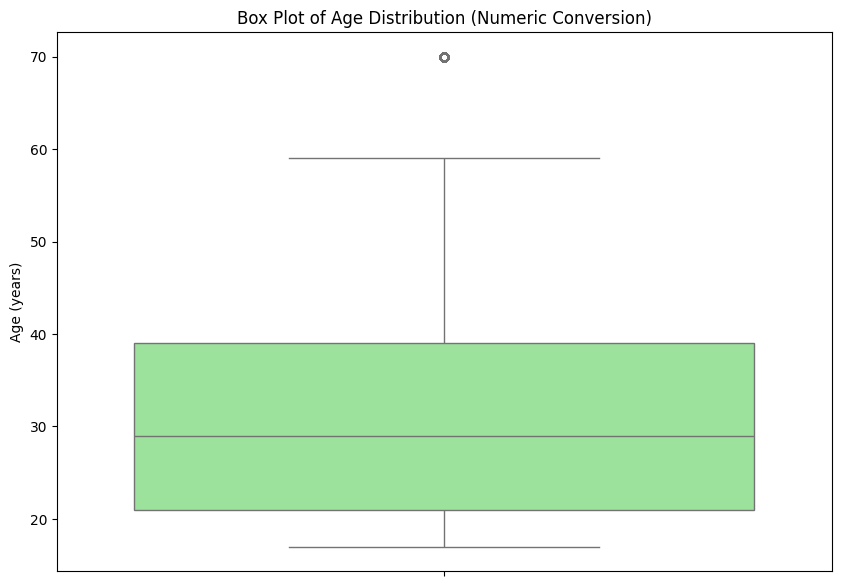

In [15]:

plt.figure(figsize=(10,7))

sns.boxplot(y=df['Age_numeric'], color="lightgreen")

plt.title("Box Plot of Age Distribution (Numeric Conversion)")
plt.ylabel("Age (years)")
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


In [16]:

QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age IS NOT NULL AND CompTotal IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)

In [17]:
# Convert compensation to numeric
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')
df = df.dropna(subset=['CompTotal'])

# Map Age ranges to simplified labels
age_map = {
    "Under 18 years old": "Under 18",
    "18-24 years old": "18-24",
    "25-34 years old": "25-34",
    "35-44 years old": "35-44",
    "45-54 years old": "45-54",
    "55-64 years old": "55-64",
    "65 years or older": "65+"
}
df['AgeGroup'] = df['Age'].map(age_map)

/tmp/ipykernel_2838/448791972.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="AgeGroup", y=df[df['CompTotal'] < 300000]['CompTotal'], data=df, palette="Set2")


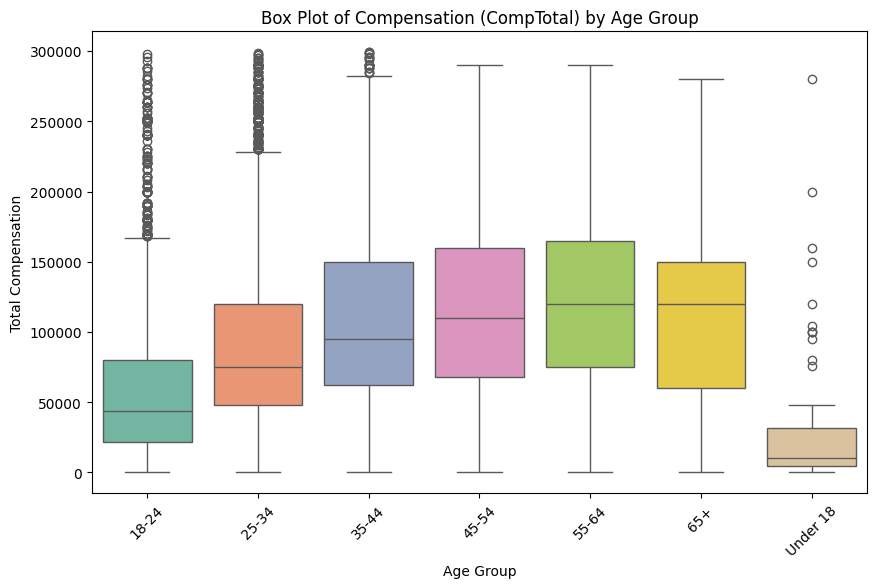

In [19]:
plt.figure(figsize=(10,6))

# sns.boxplot(x="AgeGroup", y="CompTotal", data=df, palette="Set2")
sns.boxplot(x="AgeGroup", y=df[df['CompTotal'] < 300000]['CompTotal'], data=df, palette="Set2")

plt.title("Box Plot of Compensation (CompTotal) by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Compensation")
plt.xticks(rotation=45)
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


In [20]:
QUERY = """
SELECT CompTotal, JobSatPoints_6
FROM main
WHERE CompTotal IS NOT NULL AND JobSatPoints_6 IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)

In [21]:
# Convert compensation to numeric
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')
df = df.dropna(subset=['CompTotal'])

# If JobSatPoints_6 is text, convert to numeric
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')
df = df.dropna(subset=['JobSatPoints_6'])

/tmp/ipykernel_2838/3674170863.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="JobSatPoints_6", y=df[df['CompTotal'] < 300000]['CompTotal'], data=df, palette="Set3")


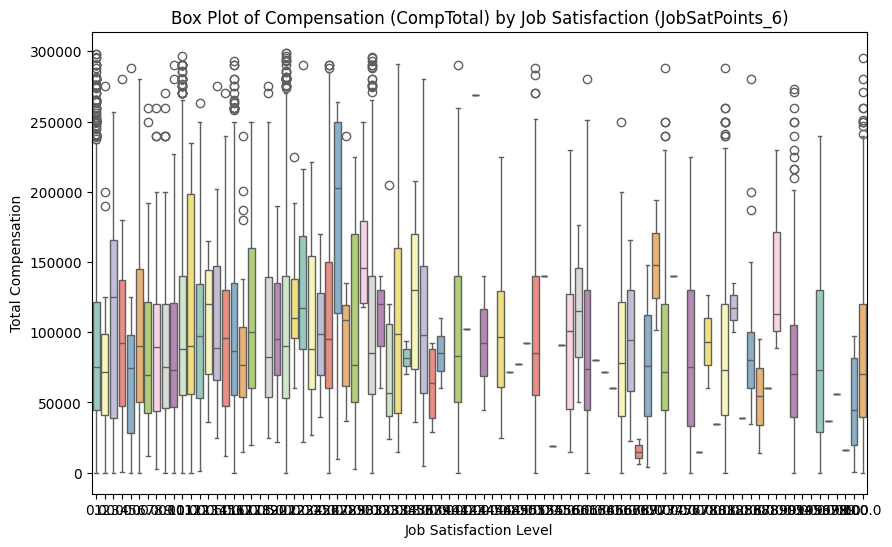

In [23]:
plt.figure(figsize=(10,6))

# sns.boxplot(x="JobSatPoints_6", y="CompTotal", data=df, palette="Set3")
sns.boxplot(x="JobSatPoints_6", y=df[df['CompTotal'] < 300000]['CompTotal'], data=df, palette="Set3")

plt.title("Box Plot of Compensation (CompTotal) by Job Satisfaction (JobSatPoints_6)")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Total Compensation")
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


In [24]:
QUERY = """
SELECT DevType, ConvertedCompYearly
FROM main
WHERE DevType IS NOT NULL AND ConvertedCompYearly IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)

In [25]:
# Split DevType into multiple rows
df = df.assign(DevType=df['DevType'].str.split(';')).explode('DevType')
df['DevType'] = df['DevType'].str.strip()

In [28]:
top5 = df['DevType'].value_counts().nlargest(5).index
df_top5 = df[df['DevType'].isin(top5)]

df_top5['ConvertedCompYearly'] = pd.to_numeric(df_top5['ConvertedCompYearly'], errors='coerce')
df_top5 = df_top5.dropna(subset=['ConvertedCompYearly'])

/tmp/ipykernel_2838/2621717794.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="DevType", y=df_top5[df_top5['ConvertedCompYearly'] < 300000]['ConvertedCompYearly'], data=df_top5, palette="Set3")


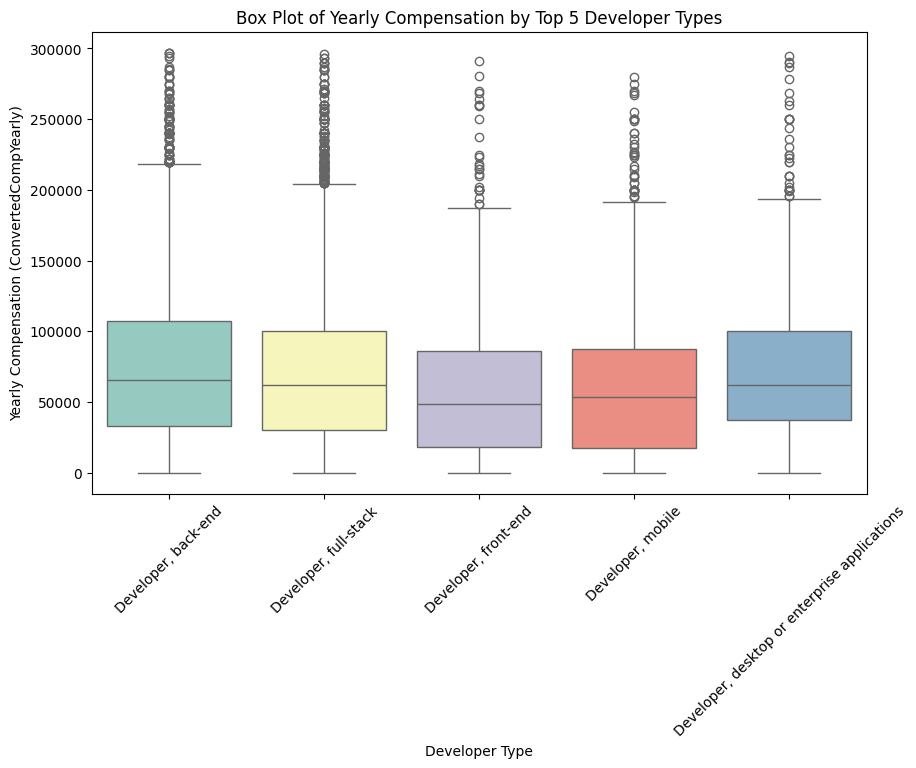

In [29]:
plt.figure(figsize=(10,6))

sns.boxplot(x="DevType", y=df_top5[df_top5['ConvertedCompYearly'] < 300000]['ConvertedCompYearly'], data=df_top5, palette="Set3")

plt.title("Box Plot of Yearly Compensation by Top 5 Developer Types")
plt.xlabel("Developer Type")
plt.ylabel("Yearly Compensation (ConvertedCompYearly)")
plt.xticks(rotation=45)
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


In [30]:
QUERY = """
SELECT Country, CompTotal
FROM main
WHERE Country IS NOT NULL AND CompTotal IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)

In [32]:
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')
df = df.dropna(subset=['CompTotal'])

top5 = df['Country'].value_counts().nlargest(5).index
df_top5 = df[df['Country'].isin(top5)]

/tmp/ipykernel_2838/2923751684.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Country", y=df_top5[df_top5['CompTotal'] < 300000]['CompTotal'], data=df_top5, palette="Set2")


([0, 1, 2, 3, 4],
 [Text(0, 0, 'United States of America'),
  Text(1, 0, 'United Kingdom of Great Britain and Northern Ireland'),
  Text(2, 0, 'Germany'),
  Text(3, 0, 'Ukraine'),
  Text(4, 0, 'India')])

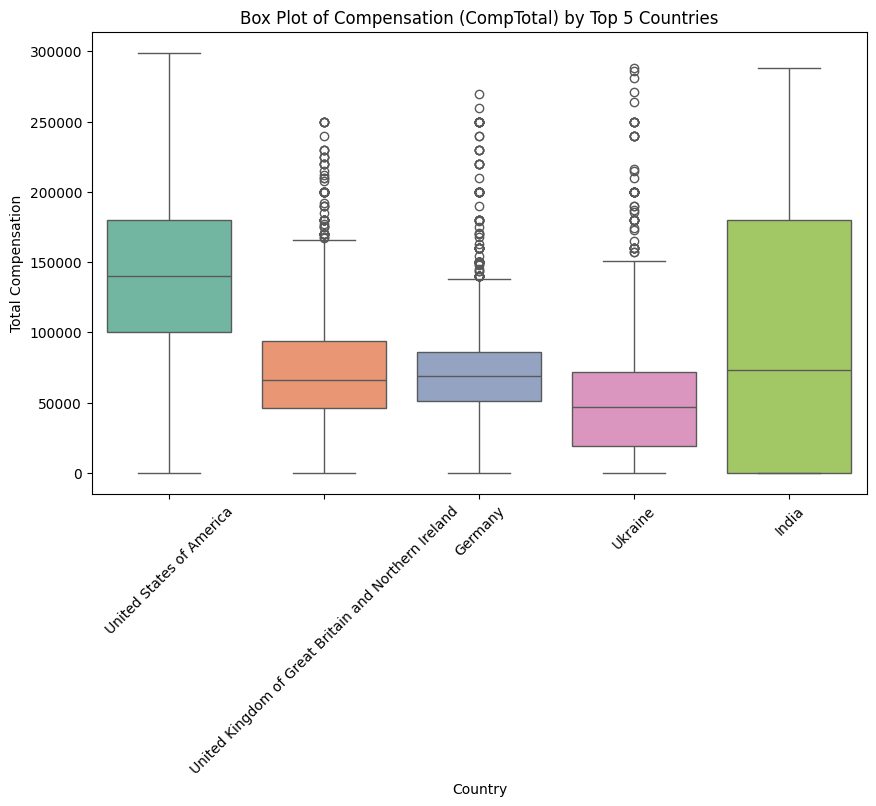

In [34]:
plt.figure(figsize=(10,6))

sns.boxplot(x="Country", y=df_top5[df_top5['CompTotal'] < 300000]['CompTotal'], data=df_top5, palette="Set2")

plt.title("Box Plot of Compensation (CompTotal) by Top 5 Countries")
plt.xlabel("Country")
plt.ylabel("Total Compensation")
plt.xticks(rotation=45)

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


In [35]:
QUERY = """
SELECT Employment, CompTotal
FROM main
WHERE Employment IS NOT NULL AND CompTotal IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)

In [36]:
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')
df = df.dropna(subset=['CompTotal'])

/tmp/ipykernel_2838/3413758965.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Employment", y=df[df['CompTotal'] < 300000]['CompTotal'], data=df, palette="Set2")


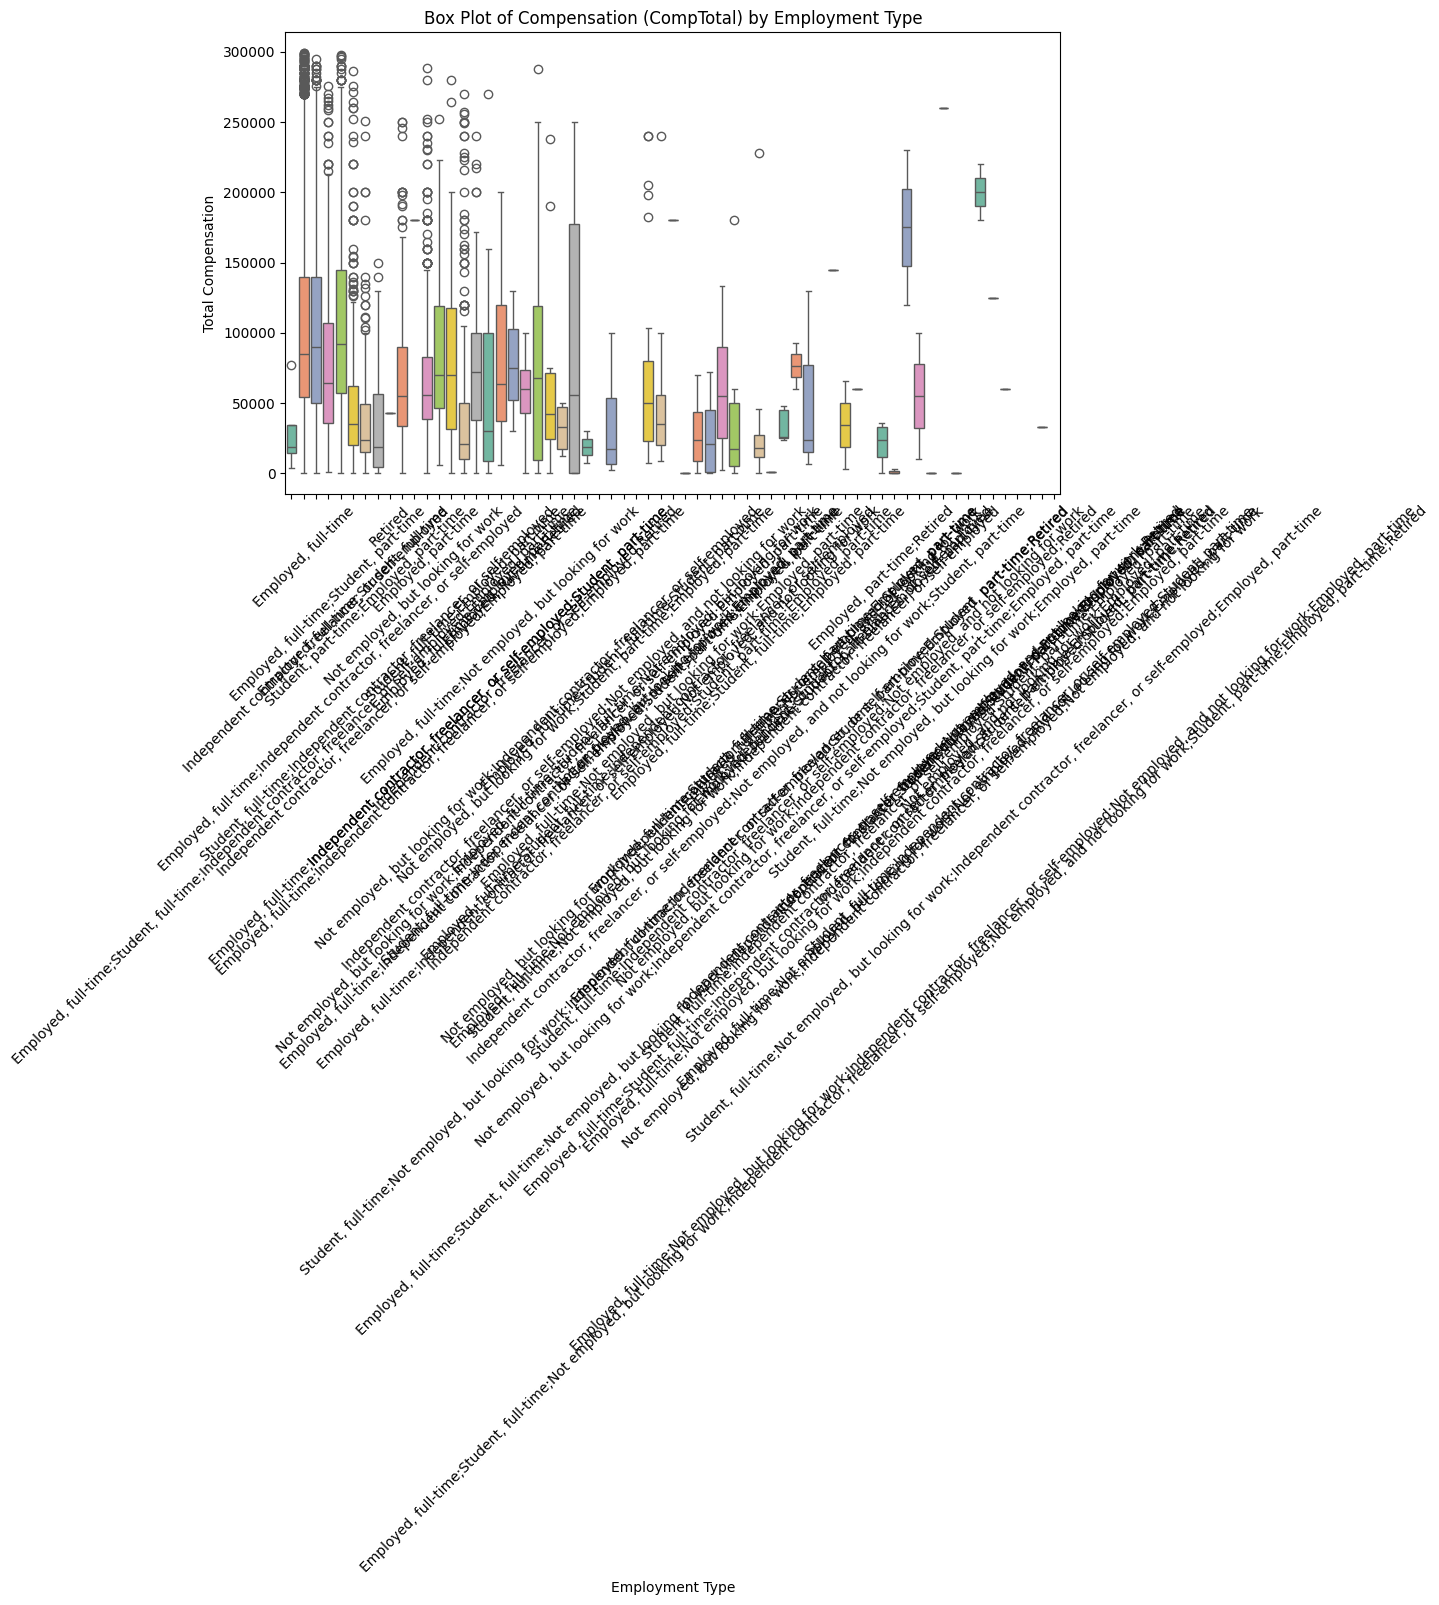

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(x="Employment", y=df[df['CompTotal'] < 300000]['CompTotal'], data=df, palette="Set2")

plt.title("Box Plot of Compensation (CompTotal) by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Total Compensation")
plt.xticks(rotation=45)
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


In [38]:
QUERY = """
SELECT YearsCodePro, JobSatPoints_6
FROM main
WHERE YearsCodePro IS NOT NULL AND JobSatPoints_6 IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)

In [39]:
def convert_years(val):
    val = str(val).strip()
    if val.lower().startswith("less than 1"):
        return 0.5
    elif val.lower().startswith("more than 50"):
        return 51
    else:
        try:
            return float(val)
        except:
            return None

df['YearsCodePro_numeric'] = df['YearsCodePro'].apply(convert_years)
df = df.dropna(subset=['YearsCodePro_numeric'])

In [40]:
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')
df = df.dropna(subset=['JobSatPoints_6'])

/tmp/ipykernel_2838/2210945087.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="JobSatPoints_6", y="YearsCodePro_numeric", data=df, palette="Set3")


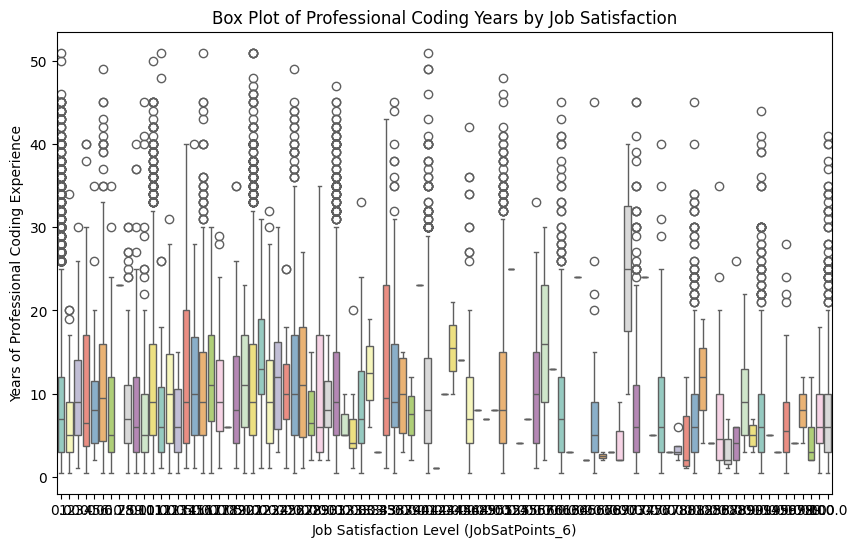

In [41]:
plt.figure(figsize=(10,6))

sns.boxplot(x="JobSatPoints_6", y="YearsCodePro_numeric", data=df, palette="Set3")


plt.title("Box Plot of Professional Coding Years by Job Satisfaction")
plt.xlabel("Job Satisfaction Level (JobSatPoints_6)")
plt.ylabel("Years of Professional Coding Experience")
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [ ]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
